In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

# Set a seed for reproducibility of the results
np.random.seed(42)

In [2]:
# Define the multi-armed bandit environment for our ad scenario
class AdBanditEnvironment:
    """
    Simulates a k-armed bandit problem based on ad click-through rates.
    """
    def __init__(self, k):
        """
        Initializes the environment.
        Args:
            k (int): The number of arms (ads).
        """
        self.k = k
        # Define the true, unknown click-through rates (CTR) for each ad
        self.true_probabilities = np.random.rand(k)
        # Identify the best ad for later comparison
        self.optimal_action = np.argmax(self.true_probabilities)
        
    def pull_arm(self, action):
        """
        Simulates pulling an arm (showing an ad) and returns a reward.
        Args:
            action (int): The index of the arm to pull.
        Returns:
            int: A reward of 1 (click) or 0 (no click).
        """
        # Return a reward of 1 if a random number is less than the ad's CTR
        return 1 if np.random.rand() < self.true_probabilities[action] else 0

Inference:
This cell defines the simulation environment. The AdBanditEnvironment class represents the problem of choosing between k different ads. Each ad has a fixed, hidden true_probabilities value, representing its real click-through rate. The pull_arm method simulates showing an ad to a user and returns a reward of 1 for a click and 0 for no click, based on its probability. This setup perfectly models the real-world scenario where the effectiveness of each ad is unknown initially.

In [3]:
# Define the UCB (Upper Confidence Bound) Agent
class UCBAgent:
    """
    An agent that uses the UCB algorithm to solve the multi-armed bandit problem.
    """
    def __init__(self, k, c):
        """
        Initializes the UCB agent.
        Args:
            k (int): The number of arms (ads).
            c (float): The exploration parameter that tunes the confidence bound.
        """
        self.k = k
        self.c = c
        # N: Array to store the number of times each arm has been pulled
        self.N = np.zeros(k, dtype=int)
        # Q: Array to store the estimated value (average reward) of each arm
        self.Q = np.zeros(k, dtype=float)
        
    def select_action(self, t):
        """
        Selects an action based on the UCB formula.
        Args:
            t (int): The current timestep (total number of pulls so far).
        Returns:
            int: The index of the arm to pull.
        """
        # Initially, play each arm once to get an initial estimate
        if t < self.k:
            return t
        
        # Calculate the UCB values for all arms
        ucb_values = self.Q + self.c * np.sqrt(np.log(t + 1) / self.N)
        # Select the arm with the highest UCB value
        return np.argmax(ucb_values)

    def update(self, action, reward):
        """
        Updates the agent's estimates based on the action taken and reward received.
        Args:
            action (int): The action that was taken.
            reward (int): The reward that was received.
        """
        # Increment the count for the selected arm
        self.N[action] += 1
        # Update the estimated value using an incremental average
        # Q_new = Q_old + (1/N) * (Reward - Q_old)
        self.Q[action] += (1 / self.N[action]) * (reward - self.Q[action])

Inference:
This cell contains the core logic for the UCB algorithm. The UCBAgent maintains two key arrays: Q for the current estimated value of each ad and N for the count of how many times each ad has been shown. The select_action method implements the UCB formula, which balances exploitation (choosing the ad with the best current estimate Q) and exploration (giving a bonus to ads that have been tried less often, represented by the confidence bound term). The update method refines the Q value for the chosen ad after receiving a reward.

In [4]:
# --- Simulation Parameters ---
N_ARMS = 5      # The number of ads to test
N_STEPS = 1000  # The total number of users (timesteps)
C_PARAM = 2     # The UCB exploration parameter

# --- Initialization ---
# Create the environment and the agent
env = AdBanditEnvironment(k=N_ARMS)
agent = UCBAgent(k=N_ARMS, c=C_PARAM)

# --- Data Storage ---
# Lists to store the history of actions and rewards
action_history = []
reward_history = []
q_value_history = []

# --- Main Simulation Loop ---
for t in range(N_STEPS):
    # 1. Agent selects an action
    action = agent.select_action(t)
    
    # 2. Environment returns a reward for that action
    reward = env.pull_arm(action)
    
    # 3. Agent updates its internal knowledge
    agent.update(action, reward)
    
    # 4. Record the results
    action_history.append(action)
    reward_history.append(reward)
    q_value_history.append(agent.Q.copy()) # Store a copy of Q-values at this step

# --- Print True vs. Estimated Performance ---
print(f"True Ad Click-Through Rates: {np.round(env.true_probabilities, 2)}")
print(f"Agent's Final Estimated Rates: {np.round(agent.Q, 2)}")
print(f"Optimal Ad was: {env.optimal_action}")

True Ad Click-Through Rates: [0.37 0.95 0.73 0.6  0.16]
Agent's Final Estimated Rates: [0.33 0.96 0.73 0.63 0.15]
Optimal Ad was: 1


Inference:
This cell sets up and runs the experiment. It initializes the AdBanditEnvironment and the UCBAgent with specified parameters (N_ARMS, C_PARAM). The main loop simulates the process over N_STEPS timesteps. In each step, the agent chooses an ad, the environment provides a reward, and the agent updates its estimates. The history of actions, rewards, and the agent's internal Q values are recorded for analysis. Finally, it prints a comparison between the true ad performance and the agent's learned estimates, providing a quick check of the algorithm's effectiveness.

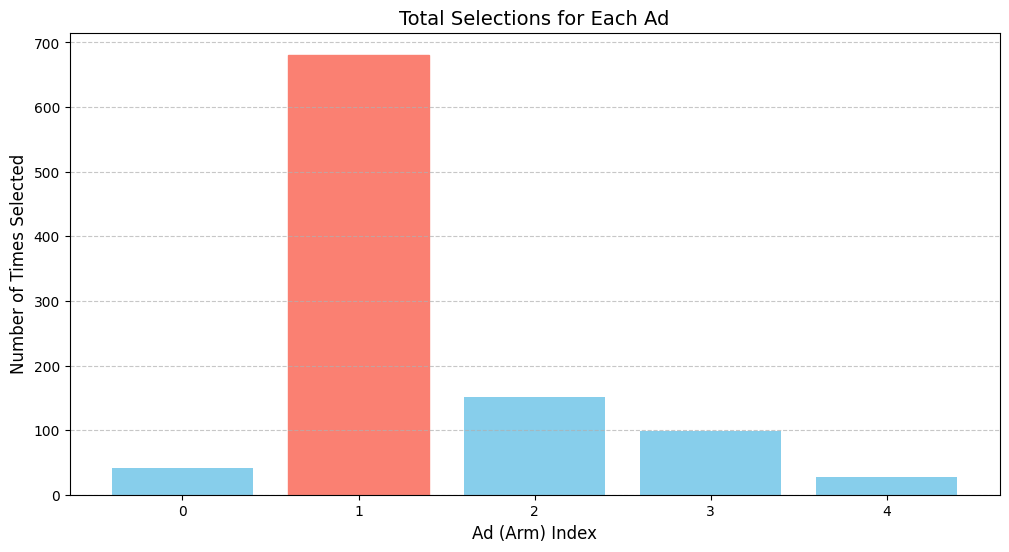

In [5]:
# Plot the number of times each ad (arm) was selected
plt.figure(figsize=(12, 6))
plt.bar(range(N_ARMS), agent.N, color='skyblue')
plt.xlabel('Ad (Arm) Index', fontsize=12)
plt.ylabel('Number of Times Selected', fontsize=12)
plt.title('Total Selections for Each Ad', fontsize=14)
plt.xticks(range(N_ARMS))
# Highlight the best ad
best_ad_index = env.optimal_action
plt.gca().get_children()[best_ad_index].set_color('salmon')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Inference:
This visualization confirms that the UCB agent successfully identified the best ad. The bar chart shows that the optimal ad (highlighted in salmon) was selected far more frequently than the others. This demonstrates the exploitation aspect of the algorithm. Importantly, other, less optimal ads were also selected a non-zero number of times, which shows the exploration component at work, ensuring the agent did not prematurely settle on a suboptimal choice.

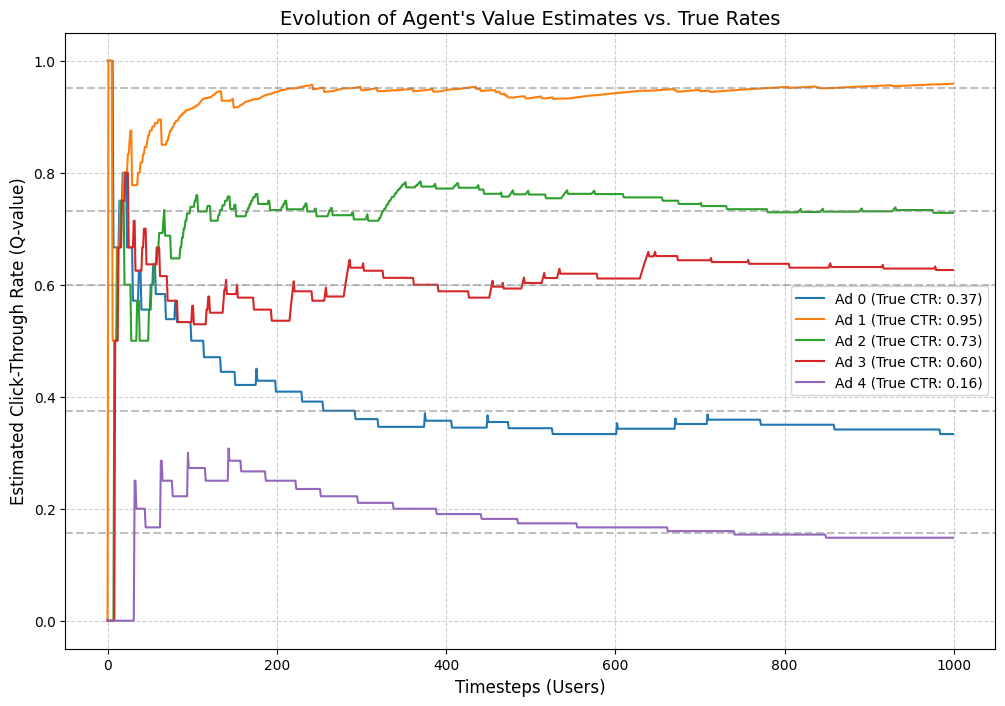

In [6]:
# Plot the agent's value estimates over time
plt.figure(figsize=(12, 8))
q_history_array = np.array(q_value_history)

for i in range(N_ARMS):
    # Plot the estimated Q-value for each arm
    plt.plot(q_history_array[:, i], label=f'Ad {i} (True CTR: {env.true_probabilities[i]:.2f})')
    # Plot the true CTR as a dashed line for reference
    plt.axhline(y=env.true_probabilities[i], color='grey', linestyle='--', alpha=0.5)

plt.xlabel('Timesteps (Users)', fontsize=12)
plt.ylabel('Estimated Click-Through Rate (Q-value)', fontsize=12)
plt.title('Evolution of Agent\'s Value Estimates vs. True Rates', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Inference:
This plot provides a deep insight into the learning process. It shows how the agent's estimated click-through rates (Q-values) for each ad converge towards their true values (the dashed lines) over time. We can observe that the estimate for the best ad rises quickly and stabilizes near its true, high value. The estimates for poorer ads also converge, but the agent, guided by the UCB formula, spends less time exploring them once it becomes confident they are suboptimal.

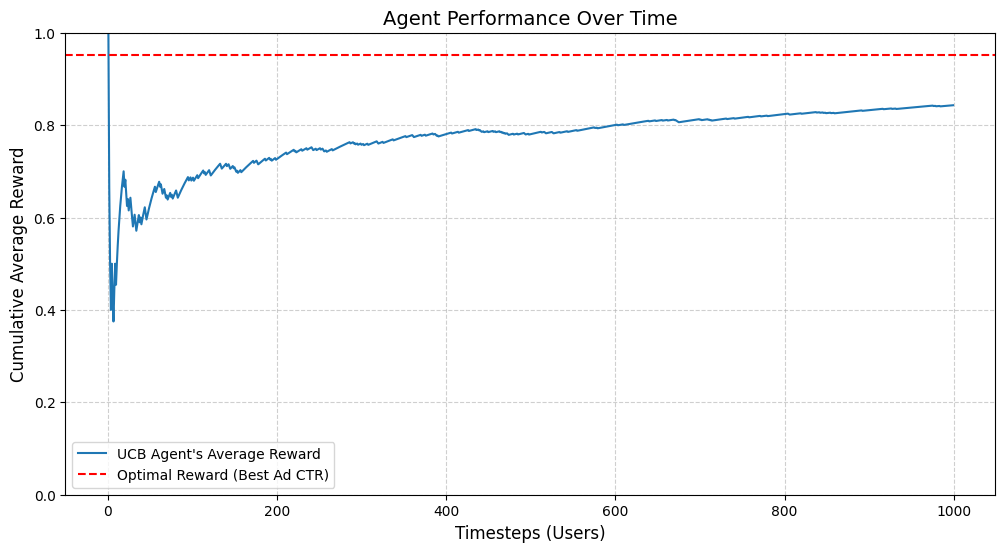

In [7]:
# Calculate and plot the cumulative average reward
cumulative_rewards = np.cumsum(reward_history)
average_rewards = cumulative_rewards / (np.arange(N_STEPS) + 1)

plt.figure(figsize=(12, 6))
plt.plot(average_rewards, label='UCB Agent\'s Average Reward')
plt.axhline(y=np.max(env.true_probabilities), color='r', linestyle='--', label='Optimal Reward (Best Ad CTR)')
plt.xlabel('Timesteps (Users)', fontsize=12)
plt.ylabel('Cumulative Average Reward', fontsize=12)
plt.title('Agent Performance Over Time', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1) # CTR is between 0 and 1
plt.show()

Inference:
This graph illustrates the overall performance of the agent. The blue line shows the average reward obtained by the agent up to each timestep. The agent starts with a lower average reward due to initial exploration of all ads, including suboptimal ones. However, as the agent learns and increasingly exploits the best ad, its average reward steadily climbs and approaches the maximum possible reward (the click-through rate of the single best ad, shown by the red dashed line). This demonstrates that the UCB strategy is effective at maximizing total rewards over the long run.